## Import data


In [6]:
import polars as pl
import datetime as dt

af2_cutoff = dt.datetime(2018, 5, 1, tzinfo=dt.timezone.utc)
boltz_cutoff = dt.datetime(2023, 6, 1, tzinfo=dt.timezone.utc)

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")
pdb_af3 = pdb_af3.with_columns(
    pl.when(pl.col("pdb_date") < af2_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("af2_pre_cutoff")
).filter(pl.col("pdb") != "8trr")
pdb_boltz = (
    pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet")
    .with_columns(
        pl.when(pl.col("pdb_date") < boltz_cutoff)
        .then(pl.lit(True))
        .otherwise(pl.lit(False))
        .alias("boltz_pre_cutoff")
    )
    .filter(pl.col("pdb") != "8trr")
)

## Summary stats


In [7]:
af3_pre = (
    pdb_af3.filter(pl.col("replication"))
    .select(pl.col("cdr_rmsd_af3_4").median())
    .item()
)
af3_post = (
    pdb_af3.filter(~pl.col("replication"))
    .select(pl.col("cdr_rmsd_af3_4").median())
    .item()
)
af2_pre = (
    pdb_af3.filter(pl.col("af2_pre_cutoff")).select(pl.col("cdr_rmsd").median()).item()
)
af2_post = (
    pdb_af3.filter(~pl.col("af2_pre_cutoff"), pl.col("cdr_rmsd").is_not_null())
    .select(pl.col("cdr_rmsd").median())
    .item()
)

print("AF3 pre: " + str(af3_pre))
print("AF3 post: " + str(af3_post))


print(f"Improvement, Pre: {af2_pre - af3_pre}")
print(f"Improvement, Post: {af2_post - af3_post}")

AF3 pre: 1.608364515573189
AF3 post: 2.428738736367039
Improvement, Pre: 2.286635484426811
Improvement, Post: 1.0662612636329611


## Plotting methods


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import mannwhitneyu


def plot_rmsd_compare(
    df_af3: pl.DataFrame,
    df_boltz: pl.DataFrame,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Compare a single RMSD type between AF3 and Boltz models.
    For each model we plot two boxplots (pre- and post-training cutoff),
    annotate legend entries with sample counts, and compute
    Spearman correlation + two-sided paired t-test on matching PDB IDs.
    """
    # Column names
    col_af3 = f"{rmsd_type}_rmsd_af3_4"
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"
    col_af2 = "cdr_rmsd"

    # Prepare pre/post subsets and counts
    af3_pre = df_af3.filter(pl.col("replication"))
    af3_post = df_af3.filter(~pl.col("replication"))
    af2_pre = df_af3.filter(pl.col("af2_pre_cutoff"))
    af2_post = df_af3.filter(~pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null())
    bolt_pre = df_boltz.filter(pl.col("boltz_pre_cutoff"))
    bolt_post = df_boltz.filter(~pl.col("boltz_pre_cutoff"))

    n_af2_pre = af2_pre.height
    n_af2_post = af2_post.height
    n_af3_pre = af3_pre.height
    n_af3_post = af3_post.height
    n_bolt_pre = bolt_pre.height
    n_bolt_post = bolt_post.height

    # Boxplot data
    pre_af2_vals = af2_pre.select(pl.col(col_af2)).to_numpy().flatten()
    post_af2_vals = af2_post.select(pl.col(col_af2)).to_numpy().flatten()
    pre_af3_vals = af3_pre.select(pl.col(col_af3)).to_numpy().flatten()
    post_af3_vals = af3_post.select(pl.col(col_af3)).to_numpy().flatten()
    pre_bolt_vals = bolt_pre.select(pl.col(col_boltz)).to_numpy().flatten()
    post_bolt_vals = bolt_post.select(pl.col(col_boltz)).to_numpy().flatten()

    def run_mwu(name, a, b):
        U, p = mannwhitneyu(a, b, alternative="less", method="auto")
        print(
            f"{name} Mann-Whitney U (less): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
        )

    run_mwu("AF2", pre_af2_vals, post_af2_vals)
    run_mwu("AF3", pre_af3_vals, post_af3_vals)
    run_mwu("Boltz", pre_bolt_vals, post_bolt_vals)

    # Set up plot
    x = np.array([0, 1, 2])
    width = 0.3
    fig, ax = plt.subplots(figsize=(8, 5))

    # plot AF2
    ax.boxplot(
        pre_af2_vals,
        positions=[x[0] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:purple", edgecolor="black"),
        whiskerprops=dict(color="tab:purple"),
        capprops=dict(color="tab:purple"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:purple"),
    )
    ax.boxplot(
        post_af2_vals,
        positions=[x[0] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:brown", edgecolor="black"),
        whiskerprops=dict(color="tab:brown"),
        capprops=dict(color="tab:brown"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:brown"),
    )

    # Plot AF3
    ax.boxplot(
        pre_af3_vals,
        positions=[x[1] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        post_af3_vals,
        positions=[x[1] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # Plot Boltz
    ax.boxplot(
        pre_bolt_vals,
        positions=[x[2] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:green", edgecolor="black"),
        whiskerprops=dict(color="tab:green"),
        capprops=dict(color="tab:green"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:green"),
    )
    ax.boxplot(
        post_bolt_vals,
        positions=[x[2] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:red", edgecolor="black"),
        whiskerprops=dict(color="tab:red"),
        capprops=dict(color="tab:red"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:red"),
    )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels(["AF2M-TCRDock", "AF3", "Boltz"])
    ax.set_ylabel(f"{rmsd_type.upper()} RMSD (Å)")
    if title:
        ax.set_title(title)

    # Legend with counts
    legend_handles = [
        Patch(
            facecolor="tab:purple", edgecolor="black", label=f"AF2 pre (n={n_af2_pre})"
        ),
        Patch(
            facecolor="tab:brown", edgecolor="black", label=f"AF2 post (n={n_af2_post})"
        ),
        Patch(
            facecolor="tab:blue", edgecolor="black", label=f"AF3 pre (n={n_af3_pre})"
        ),
        Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label=f"AF3 post (n={n_af3_post})",
        ),
        Patch(
            facecolor="tab:green",
            edgecolor="black",
            label=f"Boltz pre (n={n_bolt_pre})",
        ),
        Patch(
            facecolor="tab:red",
            edgecolor="black",
            label=f"Boltz post (n={n_bolt_post})",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    ax.legend(handles=legend_handles, loc="upper right")

    plt.tight_layout()
    return fig


# def plot_rmsd_compare_by_mhc_class(
#     df_af3: pl.DataFrame,
#     df_boltz: pl.DataFrame,
#     rmsd_type: str,
#     title: str | None = None,
#     class_col: str = "mhc_class",
#     class_order: tuple[str, str] = ("I", "II"),
# ) -> plt.Figure:
#     """
#     Stacked-by-MHC-class version of method 2, preserving original per-model colors:
#       AF2 pre=tab:purple, post=tab:brown
#       AF3 pre=tab:blue,   post=tab:orange
#       Boltz pre=tab:green, post=tab:red
#     """
#     col_af2 = "cdr_rmsd"
#     col_af3 = f"{rmsd_type}_rmsd_af3_4"
#     col_boltz = f"{rmsd_type}_rmsd_boltz_4"

#     # Determine overlapping classes in both dataframes (respect requested order)
#     af3_classes = set(df_af3.get_column(class_col).unique().to_list())
#     boltz_classes = set(df_boltz.get_column(class_col).unique().to_list())
#     present = [c for c in class_order if c in af3_classes and c in boltz_classes]
#     if not present:
#         raise ValueError(
#             f"No overlapping MHC classes from {class_order} found in '{class_col}'."
#         )

#     # Figure with one row per class; share axes
#     fig, axes = plt.subplots(
#         nrows=len(present),
#         ncols=1,
#         figsize=(8, 5 if len(present) == 1 else 9),
#         sharex=False,
#         sharey=True,
#         constrained_layout=False,
#     )
#     if len(present) == 1:
#         axes = [axes]

#     # X positions and box width
#     x = np.array([0, 1, 2])  # AF2, AF3, Boltz
#     width = 0.35

#     # Color map (original)
#     colors = {
#         "af2_pre": "tab:blue",
#         "af2_post": "tab:orange",
#         "af3_pre": "tab:blue",
#         "af3_post": "tab:orange",
#         "boltz_pre": "tab:blue",
#         "boltz_post": "tab:orange",
#     }

#     def _vals(df: pl.DataFrame, col: str) -> np.ndarray:
#         return (
#             df.select(pl.col(col)).to_numpy().flatten() if df.height else np.array([])
#         )

#     for ax, cls in zip(axes, present):
#         # Filter by class
#         af3_cls = df_af3.filter(pl.col(class_col) == cls)
#         boltz_cls = df_boltz.filter(pl.col(class_col) == cls)

#         # Pre/Post splits (drop nulls for metric)
#         af2_pre = af3_cls.filter(
#             pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null()
#         )
#         af2_post = af3_cls.filter(
#             ~pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null()
#         )
#         af3_pre = af3_cls.filter(pl.col("replication"), pl.col(col_af3).is_not_null())
#         af3_post = af3_cls.filter(~pl.col("replication"), pl.col(col_af3).is_not_null())
#         bolt_pre = boltz_cls.filter(
#             pl.col("boltz_pre_cutoff"), pl.col(col_boltz).is_not_null()
#         )
#         bolt_post = boltz_cls.filter(
#             ~pl.col("boltz_pre_cutoff"), pl.col(col_boltz).is_not_null()
#         )

#         pre_af2_vals = _vals(af2_pre, col_af2)
#         post_af2_vals = _vals(af2_post, col_af2)
#         pre_af3_vals = _vals(af3_pre, col_af3)
#         post_af3_vals = _vals(af3_post, col_af3)
#         pre_bolt_vals = _vals(bolt_pre, col_boltz)
#         post_bolt_vals = _vals(bolt_post, col_boltz)

#         print(
#             f"MHC {cls} AF2 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
#         )
#         print(
#             f"MHC {cls} AF3 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
#         )

#         print(
#             f"MHC {cls} AF3 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
#         )

#         # Optional MWU stats per class
#         def run_mwu(name, a, b):
#             if len(a) and len(b):
#                 U, p = mannwhitneyu(a, b, alternative="less", method="auto")
#                 print(
#                     f"[MHC {cls}] {name} MWU (pre < post): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
#                 )
#                 return U, p

#         # --- Draw boxplots (use original per-model colors) ---
#         # AF2
#         if len(pre_af2_vals):
#             ax.boxplot(
#                 pre_af2_vals,
#                 positions=[x[0] - width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["af2_pre"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["af2_pre"]),
#                 capprops=dict(color=colors["af2_pre"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["af2_pre"]),
#                 showfliers=False,
#                 zorder=0,
#             )

#             pos = np.random.normal(x[0] - width / 2, 0.04, len(pre_af2_vals))
#             ax.scatter(
#                 pos,
#                 pre_af2_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )

#         if len(post_af2_vals):
#             ax.boxplot(
#                 post_af2_vals,
#                 positions=[x[0] + width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["af2_post"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["af2_post"]),
#                 capprops=dict(color=colors["af2_post"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["af2_post"]),
#                 showfliers=False,
#                 zorder=0,
#             )
#             pos = np.random.normal(x[0] + width / 2, 0.04, len(post_af2_vals))
#             ax.scatter(
#                 pos,
#                 post_af2_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )

#         # AF3
#         if len(pre_af3_vals):
#             ax.boxplot(
#                 pre_af3_vals,
#                 positions=[x[1] - width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["af3_pre"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["af3_pre"]),
#                 capprops=dict(color=colors["af3_pre"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["af3_pre"]),
#                 showfliers=False,
#                 zorder=0,
#             )

#             pos = np.random.normal(x[1] - width / 2, 0.04, len(pre_af3_vals))
#             ax.scatter(
#                 pos,
#                 pre_af3_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )
#         if len(post_af3_vals):
#             ax.boxplot(
#                 post_af3_vals,
#                 positions=[x[1] + width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["af3_post"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["af3_post"]),
#                 capprops=dict(color=colors["af3_post"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["af3_post"]),
#                 showfliers=False,
#                 zorder=0,
#             )
#             pos = np.random.normal(x[1] + width / 2, 0.04, len(post_af3_vals))
#             ax.scatter(
#                 pos,
#                 post_af3_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )

#         # Boltz
#         if len(pre_bolt_vals):
#             ax.boxplot(
#                 pre_bolt_vals,
#                 positions=[x[2] - width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["boltz_pre"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["boltz_pre"]),
#                 capprops=dict(color=colors["boltz_pre"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["boltz_pre"]),
#                 showfliers=False,
#                 zorder=0,
#             )

#             pos = np.random.normal(x[2] - width / 2, 0.04, len(pre_bolt_vals))
#             ax.scatter(
#                 pos,
#                 pre_bolt_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )
#         if len(post_bolt_vals):
#             ax.boxplot(
#                 post_bolt_vals,
#                 positions=[x[2] + width / 2],
#                 widths=width,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors["boltz_post"], edgecolor="black"),
#                 whiskerprops=dict(color=colors["boltz_post"]),
#                 capprops=dict(color=colors["boltz_post"]),
#                 medianprops=dict(color="white"),
#                 flierprops=dict(markeredgecolor=colors["boltz_post"]),
#                 showfliers=False,
#                 zorder=0,
#             )
#             pos = np.random.normal(x[2] + width / 2, 0.04, len(post_bolt_vals))
#             ax.scatter(
#                 pos,
#                 post_bolt_vals,
#                 alpha=1,
#                 s=10,
#                 c="white",
#                 edgecolors="black",
#                 zorder=1,
#             )
#         # Panel label (left axis)
#         ax.tick_params(axis="y", labelsize=14)
#         ax.set_ylabel(f"MHC Class {cls}", fontsize=18)

#         # U, p = run_mwu("AF2", pre_af2_vals, post_af2_vals)
#         # if ax is axes[0]:
#         #     p = f"{p:.2e}" if p <= 0.05 else "n.s."
#         #     ax.text(
#         #         ax.get_xticks()[0],
#         #         15,
#         #         f"p={p}",
#         #         fontsize=12,
#         #         bbox=dict(alpha=0.5, boxstyle="round"),
#         #     )
#         #     U, p = run_mwu("AF2", pre_af3_vals, post_af3_vals)
#         #     p = f"{p:.2e}" if p <= 0.05 else "n.s."
#         #     ax.text(
#         #         ax.get_xticks()[2],
#         #         15,
#         #         f"p={p}",
#         #         fontsize=12,
#         #         bbox=dict(alpha=0.5, boxstyle="round"),
#         #     )
#         # else:
#         #     p = f"{p:.2e}" if p <= 0.05 else "n.s."
#         #     ax.text(
#         #         ax.get_xticks()[0],
#         #         20,
#         #         f"p={p}",
#         #         fontsize=12,
#         #         bbox=dict(alpha=0.5, boxstyle="round"),
#         #     )
#         #     U, p = run_mwu("AF2", pre_af3_vals, post_af3_vals)
#         #     p = f"{p:.2e}" if p <= 0.05 else "n.s."
#         #     ax.text(
#         #         ax.get_xticks()[2],
#         #         20,
#         #         f"p={p}",
#         #         fontsize=12,
#         #         bbox=dict(alpha=0.5, boxstyle="round"),
#         #     )
#         #     pass

#         # U, p = run_mwu("AF2", pre_bolt_vals, post_bolt_vals)
#         # p = f"{p:.2e}" if p <= 0.05 else "n.s."
#         # ax.text(
#         #     ax.get_xticks()[4],
#         #     20,
#         #     f"p={p}",
#         #     fontsize=12,
#         #     bbox=dict(alpha=0.5, boxstyle="round"),
#         # )

#         # run_mwu("AF3", pre_af3_vals, post_af3_vals)
#         # run_mwu("Boltz", pre_bolt_vals, post_bolt_vals)

#         # X ticks (only bottom panel gets labels)
#         labs = [
#             f"Included={len(pre_af2_vals)}\nNot included={len(post_af2_vals)}\n",
#             f"Included={len(pre_af3_vals)}\nNot included={len(post_af3_vals)}",
#             f"Included={len(pre_bolt_vals)}\nNot included={len(post_bolt_vals)}",
#         ]
#         if ax is axes[-1]:

#             # for i, m in enumerate(["AF2M-TCRDock", "AF3", "Boltz-2"]):
#             #     labs[i] += f"\n{m}"
#             pass

#         else:
#             for i, m in enumerate(["AF-TCRdock", "AF3", "Boltz-2"]):
#                 m = ["AF-TCRdock", "AF3", "Boltz-2"]
#                 p = [0.09, 0.48, 0.75]
#                 ax.text(p[i], 1.02, m[i], transform=ax.transAxes, fontsize=18)

#         ax.set_xticks(x)
#         ax.set_xticklabels(labs, fontsize=14)

#         # Per-panel legend with class-specific counts, preserving colors
#         legend_handles = [
#             Patch(
#                 facecolor=colors["af2_pre"],
#                 edgecolor="black",
#                 label="Incl. in model training",
#             ),
#             Patch(
#                 facecolor=colors["af2_post"],
#                 edgecolor="black",
#                 label="Not incl. in model training",
#             ),
#             # Patch(
#             #     facecolor=colors["af3_pre"],
#             #     edgecolor="black",
#             #     label=f"AF3 pre (n={len(pre_af3_vals)})",
#             # ),
#             # Patch(
#             #     facecolor=colors["af3_post"],
#             #     edgecolor="black",
#             #     label=f"AF3 post (n={len(post_af3_vals)})",
#             # ),
#             # Patch(
#             #     facecolor=colors["boltz_pre"],
#             #     edgecolor="black",
#             #     label=f"Boltz pre (n={len(pre_bolt_vals)})",
#             # ),
#             # Patch(
#             #     facecolor=colors["boltz_post"],
#             #     edgecolor="black",
#             #     label=f"Boltz post (n={len(post_bolt_vals)})",
#             # ),
#         ]

#         if cls != "II":
#             ax.legend(handles=legend_handles, loc="upper left", fontsize=11)

#     # Shared labels / title
#     fig.supylabel(f"{rmsd_type.upper()} RMSD (Å)", x=0.07, fontsize=18)
#     if title:
#         fig.suptitle(title, y=0.95, fontsize=20, x=0.55)


#     fig.tight_layout(rect=[0.06, 0.05, 0.98, 0.95])
#     return fig
def _mwu_greater(a, b):
    if len(a) and len(b):
        U, p = mannwhitneyu(a, b, alternative="greater", method="auto")
        return U, p
    return None, None


def _mwu_lesser(a, b):
    if len(a) and len(b):
        U, p = mannwhitneyu(a, b, alternative="less", method="auto")
        return U, p
    return None, None


def _mwu_two(a, b):
    if len(a) and len(b):
        U, p = mannwhitneyu(a, b, alternative="two-sided", method="auto")
        return U, p
    return None, None


def _pstr(p):
    if p is None:
        return "n/a"
    return (
        f"p={p:.1e}" if p <= 0.05 else "n.s."
    )  # guard for tiny/0 from float underflow


def plot_rmsd_compare_by_mhc_class(
    df_af3: pl.DataFrame,
    df_boltz: pl.DataFrame,
    rmsd_type: str,
    title: str | None = None,
    class_col: str = "mhc_class",
    class_order: tuple[str, str] = ("I", "II"),
) -> plt.Figure:
    """
    Stacked-by-MHC-class version of method 2, preserving original per-model colors:
      AF2 pre=tab:purple, post=tab:brown
      AF3 pre=tab:blue,   post=tab:orange
      Boltz pre=tab:green, post=tab:red
    """
    col_af2 = "cdr_rmsd"
    col_af3 = f"{rmsd_type}_rmsd_af3_4"
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"

    # Determine overlapping classes in both dataframes (respect requested order)
    af3_classes = set(df_af3.get_column(class_col).unique().to_list())
    boltz_classes = set(df_boltz.get_column(class_col).unique().to_list())
    present = [c for c in class_order if c in af3_classes and c in boltz_classes]
    if not present:
        raise ValueError(
            f"No overlapping MHC classes from {class_order} found in '{class_col}'."
        )

    # Figure with one row per class; share axes
    fig, axes = plt.subplots(
        nrows=len(present),
        ncols=1,
        figsize=(8, 5 if len(present) == 1 else 9),
        sharex=False,
        sharey=True,
        constrained_layout=False,
    )
    if len(present) == 1:
        axes = [axes]

    # X positions and box width
    x = np.array([0, 1, 2])  # AF2, AF3, Boltz
    width = 0.35

    # Color map (original)
    colors = {
        "af2_pre": "tab:blue",
        "af2_post": "tab:orange",
        "af3_pre": "tab:blue",
        "af3_post": "tab:orange",
        "boltz_pre": "tab:blue",
        "boltz_post": "tab:orange",
    }

    def _vals(df: pl.DataFrame, col: str) -> np.ndarray:
        return (
            df.select(pl.col(col)).to_numpy().flatten() if df.height else np.array([])
        )

    for ax, cls in zip(axes, present):
        # Filter by class
        af3_cls = df_af3.filter(pl.col(class_col) == cls)
        boltz_cls = df_boltz.filter(pl.col(class_col) == cls)

        # Pre/Post splits (drop nulls for metric)
        af2_pre = af3_cls.filter(
            pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null()
        )
        af2_post = af3_cls.filter(
            ~pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null()
        )
        af3_pre = af3_cls.filter(pl.col("replication"), pl.col(col_af3).is_not_null())
        af3_post = af3_cls.filter(~pl.col("replication"), pl.col(col_af3).is_not_null())
        bolt_pre = boltz_cls.filter(
            pl.col("boltz_pre_cutoff"), pl.col(col_boltz).is_not_null()
        )
        bolt_post = boltz_cls.filter(
            ~pl.col("boltz_pre_cutoff"), pl.col(col_boltz).is_not_null()
        )

        pre_af2_vals = _vals(af2_pre, col_af2)
        post_af2_vals = _vals(af2_post, col_af2)
        pre_af3_vals = _vals(af3_pre, col_af3)
        post_af3_vals = _vals(af3_post, col_af3)
        pre_bolt_vals = _vals(bolt_pre, col_boltz)
        post_bolt_vals = _vals(bolt_post, col_boltz)

        print(
            f"MHC {cls} AF2 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
        )
        print(
            f"MHC {cls} AF3 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
        )

        print(
            f"MHC {cls} AF3 median: {np.median(pre_af2_vals)}, mean: {np.median(pre_af2_vals)}"
        )

        # Optional MWU stats per class
        def run_mwu(name, a, b, alternative="less"):
            if len(a) and len(b):
                U, p = mannwhitneyu(a, b, alternative=alternative, method="auto")
                print(
                    f"[MHC {cls}] {name} MWU (pre < post): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
                )
                return U, p

        # --- Draw boxplots (use original per-model colors) ---
        # AF2
        if len(pre_af2_vals):
            ax.boxplot(
                pre_af2_vals,
                positions=[x[0] - width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["af2_pre"], edgecolor="black"),
                whiskerprops=dict(color=colors["af2_pre"]),
                capprops=dict(color=colors["af2_pre"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["af2_pre"]),
                showfliers=False,
                zorder=0,
            )

            pos = np.random.normal(x[0] - width / 2, 0.04, len(pre_af2_vals))
            ax.scatter(
                pos,
                pre_af2_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        if len(post_af2_vals):
            ax.boxplot(
                post_af2_vals,
                positions=[x[0] + width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["af2_post"], edgecolor="black"),
                whiskerprops=dict(color=colors["af2_post"]),
                capprops=dict(color=colors["af2_post"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["af2_post"]),
                showfliers=False,
                zorder=0,
            )
            pos = np.random.normal(x[0] + width / 2, 0.04, len(post_af2_vals))
            ax.scatter(
                pos,
                post_af2_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        # AF3
        if len(pre_af3_vals):
            ax.boxplot(
                pre_af3_vals,
                positions=[x[1] - width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["af3_pre"], edgecolor="black"),
                whiskerprops=dict(color=colors["af3_pre"]),
                capprops=dict(color=colors["af3_pre"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["af3_pre"]),
                showfliers=False,
                zorder=0,
            )

            pos = np.random.normal(x[1] - width / 2, 0.04, len(pre_af3_vals))
            ax.scatter(
                pos,
                pre_af3_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )
        if len(post_af3_vals):
            ax.boxplot(
                post_af3_vals,
                positions=[x[1] + width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["af3_post"], edgecolor="black"),
                whiskerprops=dict(color=colors["af3_post"]),
                capprops=dict(color=colors["af3_post"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["af3_post"]),
                showfliers=False,
                zorder=0,
            )
            pos = np.random.normal(x[1] + width / 2, 0.04, len(post_af3_vals))
            ax.scatter(
                pos,
                post_af3_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        # Boltz
        if len(pre_bolt_vals):
            ax.boxplot(
                pre_bolt_vals,
                positions=[x[2] - width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["boltz_pre"], edgecolor="black"),
                whiskerprops=dict(color=colors["boltz_pre"]),
                capprops=dict(color=colors["boltz_pre"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["boltz_pre"]),
                showfliers=False,
                zorder=0,
            )

            pos = np.random.normal(x[2] - width / 2, 0.04, len(pre_bolt_vals))
            ax.scatter(
                pos,
                pre_bolt_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )
        if len(post_bolt_vals):
            ax.boxplot(
                post_bolt_vals,
                positions=[x[2] + width / 2],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colors["boltz_post"], edgecolor="black"),
                whiskerprops=dict(color=colors["boltz_post"]),
                capprops=dict(color=colors["boltz_post"]),
                medianprops=dict(color="white"),
                flierprops=dict(markeredgecolor=colors["boltz_post"]),
                showfliers=False,
                zorder=0,
            )
            pos = np.random.normal(x[2] + width / 2, 0.04, len(post_bolt_vals))
            ax.scatter(
                pos,
                post_bolt_vals,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        # Tests: AF2 vs AF3/Boltz (AF2 greater ⇒ competitor lower RMSD = better)
        _, p_af3_pre = _mwu_two(pre_af2_vals, pre_af3_vals)
        _, p_boltz_pre = _mwu_two(pre_af2_vals, pre_bolt_vals)
        _, p_af3_post = _mwu_two(post_af2_vals, post_af3_vals)
        _, p_boltz_post = _mwu_two(post_af2_vals, post_bolt_vals)

        _, p_pre_af3_boltz = _mwu_two(pre_af3_vals, pre_bolt_vals)
        _, p_post_af3_boltz = _mwu_two(post_af3_vals, post_bolt_vals)

        # U, p = run_mwu("AF2", pre_af2_vals, post_af2_vals)
        # U, p = run_mwu("AF3", pre_af3_vals, post_af3_vals)
        # U, p = run_mwu("Boltz-2", pre_bolt_vals, post_bolt_vals)

        # U, p = run_mwu(
        #     "AF3 vs Boltz-2", pre_af3_vals, pre_bolt_vals
        # )
        # U, p = run_mwu(
        #     "AF3 vs Boltz-2", post_af3_vals, post_bolt_vals
        # )

        h = 0.3

        # Just place p-values above AF3 and Boltz halves
        if p_af3_pre is not None:

            x1 = ax.get_xticks()[0]
            x2 = ax.get_xticks()[2]
            y1 = 19
            y2 = y1 + h

            ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
            ax.text(
                (x1 + x2) * 0.5,
                y2,
                _pstr(p_af3_pre),
                ha="center",
                va="bottom",
                fontsize=11,
                # bbox=dict(alpha=0.5, boxstyle="round"),
            )

        if p_af3_post is not None:
            x1 = ax.get_xticks()[1]
            x2 = ax.get_xticks()[3]
            y1 = 17
            y2 = y1 + h

            ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
            ax.text(
                (x1 + x2) * 0.5,
                y2,
                _pstr(p_af3_post),
                ha="center",
                va="bottom",
                fontsize=11,
                # bbox=dict(alpha=0.5, boxstyle="round"),
            )
            # ax.text(
            #     ax.get_xticks()[3],
            #     13 if cls == "I" else 18,
            #     _pstr(p_af3_post),
            #     ha="center",
            #     va="bottom",
            #     fontsize=11,
            #     bbox=dict(alpha=0.5, boxstyle="round"),
            # )
        # if p_boltz_pre is not None:
        #     x1 = ax.get_xticks()[0]
        #     x2 = ax.get_xticks()[4]
        #     y1 = 14.5
        #     y2 = y1 + h

        #     ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
        #     ax.text(
        #         (x1 + x2) * 0.5,
        #         y2,
        #         _pstr(p_boltz_pre),
        #         ha="center",
        #         va="bottom",
        #         fontsize=11,
        #         # bbox=dict(alpha=0.5, boxstyle="round"),
        #     )
        #     # ax.text(
        #     #     ax.get_xticks()[4],
        #     #     20,
        #     #     _pstr(p_boltz_pre),
        #     #     ha="center",
        #     #     va="bottom",
        #     #     fontsize=11,
        #     #     bbox=dict(alpha=0.5, boxstyle="round"),
        #     # )

        # if p_boltz_post is not None:
        #     x1 = ax.get_xticks()[1]
        #     x2 = ax.get_xticks()[5]
        #     y1 = 12.5
        #     y2 = y1 + h

        #     ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
        #     ax.text(
        #         (x1 + x2) * 0.5,
        #         y2,
        #         _pstr(p_boltz_post),
        #         ha="center",
        #         va="bottom",
        #         fontsize=11,
        #         # bbox=dict(alpha=0.5, boxstyle="round"),
        #     )
        #     # ax.text(
        #     #     ax.get_xticks()[5],
        #     #     18,
        #     #     _pstr(p_boltz_post),
        #     #     ha="center",
        #     #     va="bottom",
        #     #     fontsize=11,
        #     #     bbox=dict(alpha=0.5, boxstyle="round"),
        #     # )

        if p_pre_af3_boltz is not None:
            x1 = ax.get_xticks()[2]
            x2 = ax.get_xticks()[4]
            y1 = 14.5
            y2 = y1 + h

            ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
            ax.text(
                (x1 + x2) * 0.5,
                y2,
                _pstr(p_pre_af3_boltz),
                ha="center",
                va="bottom",
                fontsize=11,
            )

        if p_post_af3_boltz is not None:
            x1 = ax.get_xticks()[3]
            x2 = ax.get_xticks()[5]
            y1 = 12.5
            y2 = y1 + h

            ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1, c="black")
            ax.text(
                (x1 + x2) * 0.5,
                y2,
                _pstr(p_post_af3_boltz),
                ha="center",
                va="bottom",
                fontsize=11,
            )

        # Panel label (left axis)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_ylabel(f"MHC Class {cls}", fontsize=18)

        # U, p = run_mwu("AF2", pre_bolt_vals, post_bolt_vals)
        # p = f"{p:.2e}" if p <= 0.05 else "n.s."
        # ax.text(
        #     ax.get_xticks()[4],
        #     20,
        #     f"p={p}",
        #     fontsize=12,
        #     bbox=dict(alpha=0.5, boxstyle="round"),
        # )

        # run_mwu("AF3", pre_af3_vals, post_af3_vals)
        # run_mwu("Boltz", pre_bolt_vals, post_bolt_vals)

        # X ticks (only bottom panel gets labels)
        labs = [
            f"Pre-training={len(pre_af2_vals)}\nPost-training={len(post_af2_vals)}\n",
            f"Pre-training={len(pre_af3_vals)}\nPost-training={len(post_af3_vals)}",
            f"Pre-training={len(pre_bolt_vals)}\nPost-training={len(post_bolt_vals)}",
        ]
        if ax is axes[-1]:

            # for i, m in enumerate(["AF2M-TCRDock", "AF3", "Boltz-2"]):
            #     labs[i] += f"\n{m}"
            pass

        else:
            for i, m in enumerate(["AF-TCRdock", "AF3", "Boltz-2"]):
                m = ["AF-TCRdock", "AF3", "Boltz-2"]
                p = [0.09, 0.48, 0.75]
                ax.text(p[i], 1.02, m[i], transform=ax.transAxes, fontsize=18)

        ax.set_xticks(x)
        ax.set_xticklabels(labs, fontsize=14)

        # Per-panel legend with class-specific counts, preserving colors
        legend_handles = [
            Patch(
                facecolor=colors["af2_pre"],
                edgecolor="black",
                label="Pre-training",
            ),
            Patch(
                facecolor=colors["af2_post"],
                edgecolor="black",
                label="Post-training",
            ),
            # Patch(
            #     facecolor=colors["af3_pre"],
            #     edgecolor="black",
            #     label=f"AF3 pre (n={len(pre_af3_vals)})",
            # ),
            # Patch(
            #     facecolor=colors["af3_post"],
            #     edgecolor="black",
            #     label=f"AF3 post (n={len(post_af3_vals)})",
            # ),
            # Patch(
            #     facecolor=colors["boltz_pre"],
            #     edgecolor="black",
            #     label=f"Boltz pre (n={len(pre_bolt_vals)})",
            # ),
            # Patch(
            #     facecolor=colors["boltz_post"],
            #     edgecolor="black",
            #     label=f"Boltz post (n={len(post_bolt_vals)})",
            # ),
        ]

        if cls != "II":
            ax.legend(handles=legend_handles, loc="upper right", fontsize=11)

    # Shared labels / title
    fig.supylabel(f"{rmsd_type.upper()} RMSD (Å)", x=0.07, fontsize=18)
    if title:
        fig.suptitle(title, y=0.95, fontsize=20, x=0.55)

    fig.tight_layout(rect=[0.06, 0.05, 0.98, 0.95])
    return fig

MHC I AF2 median: 4.44, mean: 4.44
MHC I AF3 median: 4.44, mean: 4.44
MHC I AF3 median: 4.44, mean: 4.44
MHC II AF2 median: 2.96, mean: 2.96
MHC II AF3 median: 2.96, mean: 2.96
MHC II AF3 median: 2.96, mean: 2.96


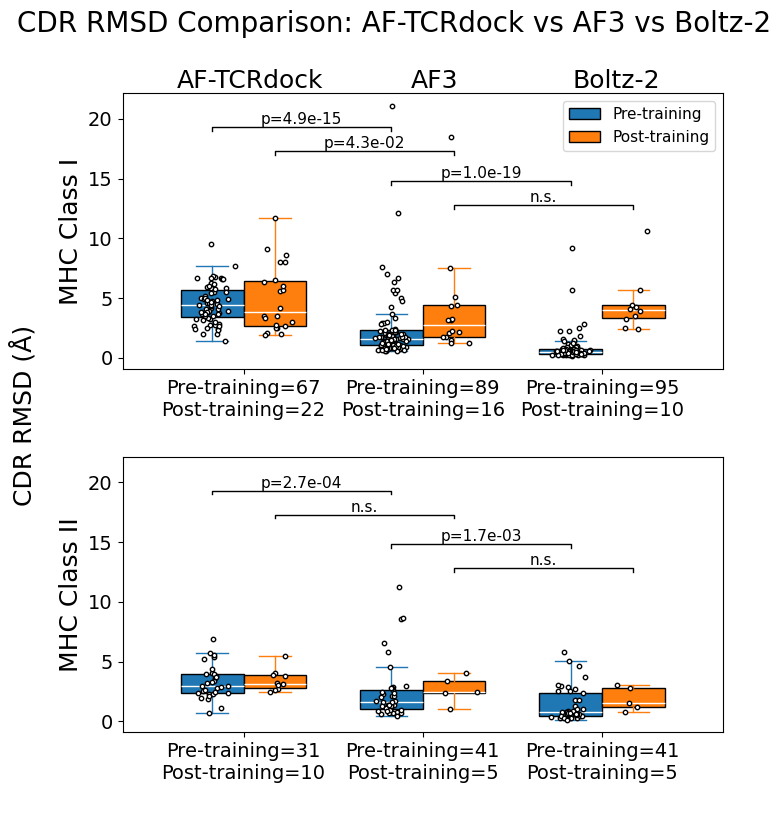

In [5]:
_ = plot_rmsd_compare_by_mhc_class(
    pdb_af3,
    pdb_boltz,
    "cdr",
    title="CDR RMSD Comparison: AF-TCRdock vs AF3 vs Boltz-2",
)

In [6]:
from scipy.stats import mannwhitneyu

for mhc_class in ["I", "II"]:
    print(f"MHC Class {mhc_class}")
    af2_pre = (
        pdb_af3.filter(
            pl.col("replication"),
            pl.col("af2_pre_cutoff"),
            pl.col("mhc_class") == mhc_class,
        )
        .select(pl.col("cdr_rmsd"))
        .to_series()
        .to_numpy()
    )
    af3_pre = (
        pdb_af3.filter(pl.col("replication"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_af3_4"))
        .to_series()
        .to_numpy()
    )

    U, p = mannwhitneyu(af2_pre, af3_pre, alternative="greater")
    print(f"  AF2 vs AF3 pre-training cutoff: U={U}, p={p}")

    af2_post = (
        pdb_af3.filter(
            pl.col("replication"),
            ~pl.col("af2_pre_cutoff"),
            pl.col("mhc_class") == mhc_class,
        )
        .select(pl.col("cdr_rmsd"))
        .to_series()
        .to_numpy()
    )
    af3_post = (
        pdb_af3.filter(~pl.col("replication"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_af3_4"))
        .to_series()
        .to_numpy()
    )
    U, p = mannwhitneyu(af2_post, af3_post, alternative="greater")
    print(f"  AF2 vs AF3 post-training cutoff: U={U}, p={p}")

MHC Class I
  AF2 vs AF3 pre-training cutoff: U=5169.0, p=2.440714618804772e-15
  AF2 vs AF3 post-training cutoff: U=245.0, p=0.02142110874995991
MHC Class II
  AF2 vs AF3 pre-training cutoff: U=956.0, p=0.00013674106857761875
  AF2 vs AF3 post-training cutoff: U=36.0, p=0.10323010323010323


In [7]:
from scipy.stats import mannwhitneyu


boltz_pre = (
    pdb_boltz.filter(pl.col("boltz_pre_cutoff"))
    .select(pl.col("cdr_rmsd_boltz_4"))
    .to_series()
    .to_numpy()
)
af3_pre = (
    pdb_af3.filter(pl.col("replication"))
    .select(pl.col("cdr_rmsd_af3_4"))
    .to_series()
    .to_numpy()
)

U, p = mannwhitneyu(boltz_pre, af3_pre, alternative="greater")
print(f"Boltz-2 > AF3 pre-training cutoff: U={U}, p={p}")
U, p = mannwhitneyu(boltz_pre, af3_pre, alternative="less")
print(f"Boltz-2 < AF3 pre-training cutoff: U={U}, p={p}")

boltz_post = (
    pdb_boltz.filter(~pl.col("boltz_pre_cutoff"))
    .select(pl.col("cdr_rmsd_boltz_4"))
    .to_series()
    .to_numpy()
)
af3_post = (
    pdb_af3.filter(~pl.col("replication"))
    .select(pl.col("cdr_rmsd_af3_4"))
    .to_series()
    .to_numpy()
)
U, p = mannwhitneyu(boltz_post, af3_post, alternative="less")
print(f"Boltz-2 < AF3 post-training cutoff: U={U}, p={p}")
U, p = mannwhitneyu(boltz_post, af3_post, alternative="greater")
print(f"Boltz-2 > AF3 post-training cutoff: U={U}, p={p}")

U, p = mannwhitneyu(boltz_post, af3_post, alternative="two-sided")
print(f"Boltz-2 = AF3 post-training cutoff: U={U}, p={p}")

Boltz-2 > AF3 pre-training cutoff: U=3012.0, p=1.0
Boltz-2 < AF3 pre-training cutoff: U=3012.0, p=7.621279127166202e-21
Boltz-2 < AF3 post-training cutoff: U=180.0, p=0.7697458517950501
Boltz-2 > AF3 post-training cutoff: U=180.0, p=0.24011809621498892
Boltz-2 = AF3 post-training cutoff: U=180.0, p=0.48023619242997784


In [8]:
from scipy.stats import mannwhitneyu

for mhc_class in ["I", "II"]:
    print(f"MHC Class {mhc_class}")
    boltz_pre = (
        pdb_boltz.filter(pl.col("boltz_pre_cutoff"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_boltz_4"))
        .to_series()
        .to_numpy()
    )
    af3_pre = (
        pdb_af3.filter(pl.col("replication"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_af3_4"))
        .to_series()
        .to_numpy()
    )

    U, p = mannwhitneyu(boltz_pre, af3_pre, alternative="greater")
    print(f"Boltz-2 > AF3 pre-training cutoff: U={U}, p={p}")
    U, p = mannwhitneyu(boltz_pre, af3_pre, alternative="less")
    print(f"Boltz-2 < AF3 pre-training cutoff: U={U}, p={p}")

    boltz_post = (
        pdb_boltz.filter(~pl.col("boltz_pre_cutoff"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_boltz_4"))
        .to_series()
        .to_numpy()
    )
    af3_post = (
        pdb_af3.filter(~pl.col("replication"), pl.col("mhc_class") == mhc_class)
        .select(pl.col("cdr_rmsd_af3_4"))
        .to_series()
        .to_numpy()
    )
    U, p = mannwhitneyu(boltz_post, af3_post, alternative="less")
    print(f"Boltz-2 < AF3 post-training cutoff: U={U}, p={p}")
    U, p = mannwhitneyu(boltz_post, af3_post, alternative="greater")
    print(f"Boltz-2 > AF3 post-training cutoff: U={U}, p={p}")

MHC Class I
Boltz-2 > AF3 pre-training cutoff: U=946.0, p=1.0
Boltz-2 < AF3 pre-training cutoff: U=946.0, p=5.0576142755492325e-20
Boltz-2 < AF3 post-training cutoff: U=112.0, p=0.9566345675862287
Boltz-2 > AF3 post-training cutoff: U=112.0, p=0.0484375375131373
MHC Class II
Boltz-2 > AF3 pre-training cutoff: U=501.0, p=0.999192446353812
Boltz-2 < AF3 pre-training cutoff: U=501.0, p=0.0008335889129353883
Boltz-2 < AF3 post-training cutoff: U=8.0, p=0.21031746031746032
Boltz-2 > AF3 post-training cutoff: U=8.0, p=0.8452380952380952


AF2 Mann-Whitney U (less): U=133.500, p=0.262, n_pre=31, n_post=10
AF3 Mann-Whitney U (less): U=67.000, p=0.112, n_pre=41, n_post=5
Boltz Mann-Whitney U (less): U=59.000, p=0.0661, n_pre=41, n_post=5


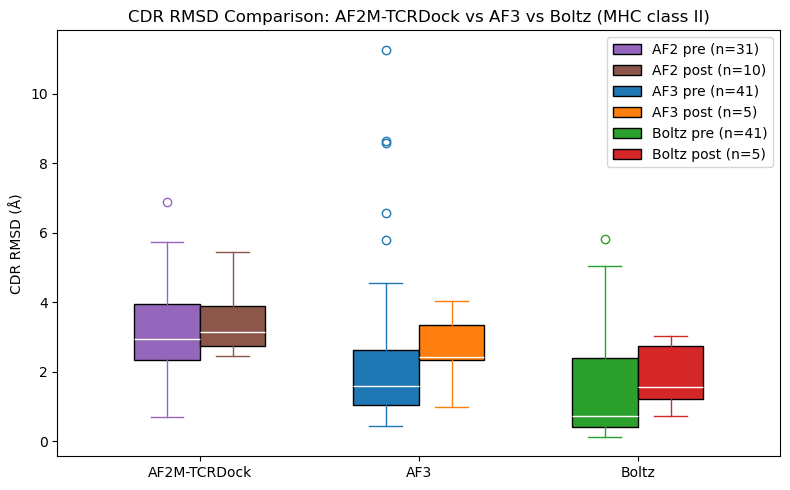

In [9]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "cdr",
    title="CDR RMSD Comparison: AF2M-TCRDock vs AF3 vs Boltz (MHC class II)",
)

AF2 Mann-Whitney U (less): U=739.500, p=0.511, n_pre=67, n_post=22
AF3 Mann-Whitney U (less): U=396.000, p=0.00245, n_pre=89, n_post=16
Boltz Mann-Whitney U (less): U=20.000, p=3.5e-07, n_pre=95, n_post=10


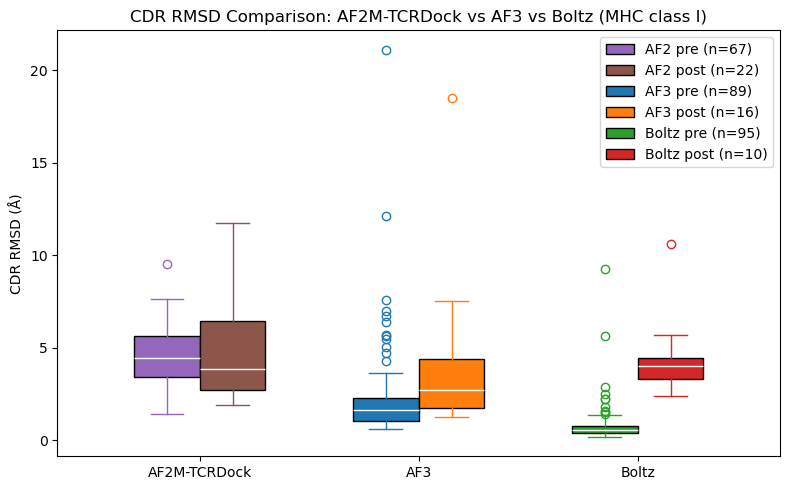

In [10]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "cdr",
    title="CDR RMSD Comparison: AF2M-TCRDock vs AF3 vs Boltz (MHC class I)",
)